In [1]:
from modules.histogram_maker import SafeHistogramMaker, create_histogram_maker_from_file
from modules.add_invariant_mass import add_invariant_mass
from modules.add_jet_control_parameters import add_jet_control_parameters
import dask.dataframe as dd
import numpy as np

In [2]:
# Caricamento dati

#file_path = "data/ZJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS54000001.parquet"
file_path = "data/WJetsToQQ_13TeV-madgraphMLM-pythia8-NEVENT10000-RS45000001.parquet"
parameters = [
    # Jets
    "FullReco_JetAK4_PT",
    "FullReco_JetAK4_Eta",
    "FullReco_JetAK4_Phi",
    "FullReco_JetAK4_Mass",
    "FullReco_JetAK4_Charge",
    "FullReco_JetAK4_Constituents",

    #Contituents
    "FullReco_PFCand_PT",
    "FullReco_PFCand_Eta",
    "FullReco_PFCand_Phi",
    "FullReco_PFCand_Charge",
    "FullReco_PFCand_Mass",
    "FullReco_PFCand_fUniqueID",
    "FullReco_PFCand_PID"
]

ddf = dd.read_parquet(file_path, parameters)

# Aggiungi massa invariante
ddf_im = add_invariant_mass(ddf, use_leading=True, n_leading=2)

In [3]:
print("numero di eventi =", len(ddf["FullReco_JetAK4_PT"]))

n=5

# per accedere ai primi n eventi
pt_first = ddf['FullReco_JetAK4_PT'].head(n)
print("######## First n pts: #########\n", pt_first)

# per accedere all'evento n esimo
pt_n = ddf['FullReco_JetAK4_PT'].loc[n].compute()
print("\n######### pt in index n: #########\n", pt_n)

# altri comandi
print("\n######### usando [0] ottengo i dati associati al idx 0: #########\n", pt_first[0])
print("\n######### usando .iloc[0] ottengo i dati associati al idx 0: #########\n", pt_first.iloc[0])
print("\n######### usando [0][0] ottengo l'elemento 0 nel idx 0: #########\n", pt_first[0][0])

numero di eventi = 9984
######## First n pts: #########
 0        [60.53, 54.8, 36.2, 24.28, 21.6, 21.1, 15.35]
1                         [30.03, 27.45, 19.33, 17.62]
2                          [50.9, 28.39, 24.25, 15.53]
3    [38.8, 28.33, 25.98, 24.86, 18.14, 17.31, 17.2...
4    [45.12, 29.73, 25.48, 21.9, 20.11, 19.78, 19.7...
Name: FullReco_JetAK4_PT, dtype: object

######### pt in index n: #########
 5    [55.78, 52.47, 43.4, 40.22, 37.44, 24.62, 21.4...
Name: FullReco_JetAK4_PT, dtype: object

######### usando [0] ottengo i dati associati al idx 0: #########
 [60.53 54.8  36.2  24.28 21.6  21.1  15.35]

######### usando .iloc[0] ottengo i dati associati al idx 0: #########
 [60.53 54.8  36.2  24.28 21.6  21.1  15.35]

######### usando [0][0] ottengo l'elemento 0 nel idx 0: #########
 60.53


/eos/home-i00/d/deyang/Fundation-Model-for-Particle-Physics/collide2v/modules/add_jet_control_parameters.py:128: RuntimeWarning: overflow encountered in scalar power
  inv_mass_sq = total_e**2 - total_px**2 - total_py**2 - total_pz**2
/eos/home-i00/d/deyang/Fundation-Model-for-Particle-Physics/collide2v/modules/add_jet_control_parameters.py:128: RuntimeWarning: invalid value encountered in scalar subtract
  inv_mass_sq = total_e**2 - total_px**2 - total_py**2 - total_pz**2
/eos/home-i00/d/deyang/Fundation-Model-for-Particle-Physics/collide2v/modules/add_jet_control_parameters.py:120: RuntimeWarning: overflow encountered in scalar power
  e = np.sqrt(pt**2 + pz**2 + mass**2)
/eos/home-i00/d/deyang/Fundation-Model-for-Particle-Physics/collide2v/modules/add_jet_control_parameters.py:125: RuntimeWarning: overflow encountered in scalar add
  sum_pt = np.sqrt(total_px**2 + total_py**2)
/eos/home-i00/d/deyang/Fundation-Model-for-Particle-Physics/collide2v/modules/add_jet_control_parameters.py

Appiattimento colonna: FullReco_JetAK4_PT
  Trovati 57,563 valori validi

--- FullReco_JetAK4_PT ---
  Elementi validi: 57,479
  Range dati: [15.008, 428.500]


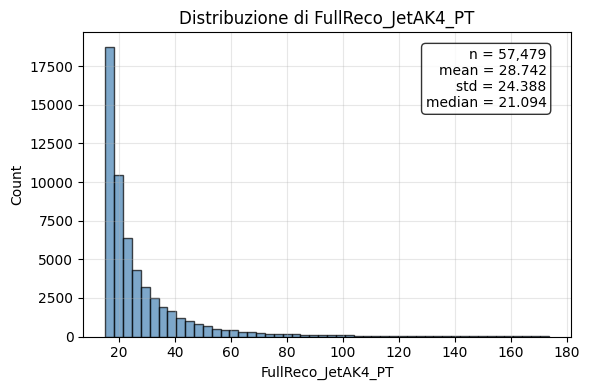

Appiattimento colonna: FullReco_JetAK4_Eta
  Trovati 57,563 valori validi

--- FullReco_JetAK4_Eta ---
  Elementi validi: 57,451
  Range dati: [-4.859, 4.891]


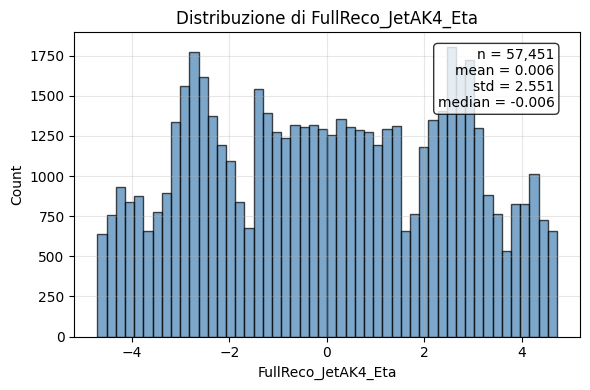

Appiattimento colonna: FullReco_JetAK4_Phi
  Trovati 57,563 valori validi

--- FullReco_JetAK4_Phi ---
  Elementi validi: 57,461
  Range dati: [-3.135, 3.135]


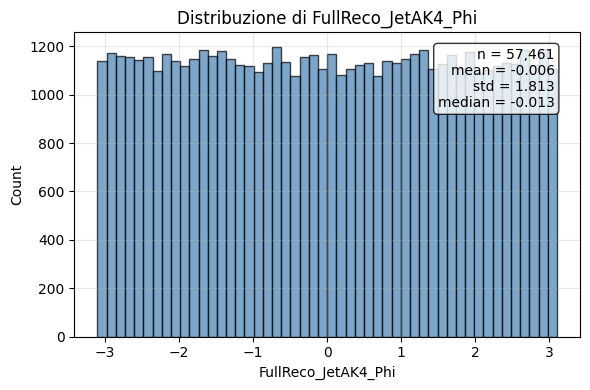

Appiattimento colonna: FullReco_JetAK4_Charge
  Trovati 57,563 valori validi

--- FullReco_JetAK4_Charge ---
  Elementi validi: 57,563
  Range dati: [-1.000, 1.000]


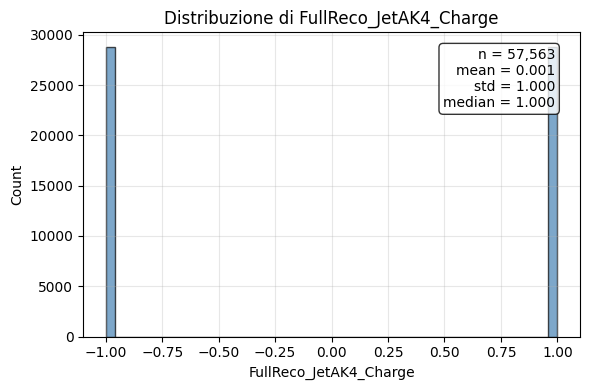

Appiattimento colonna: FullReco_JetAK4_Mass
  Trovati 57,563 valori validi

--- FullReco_JetAK4_Mass ---
  Elementi validi: 57,447
  Range dati: [-7.719, 44.062]


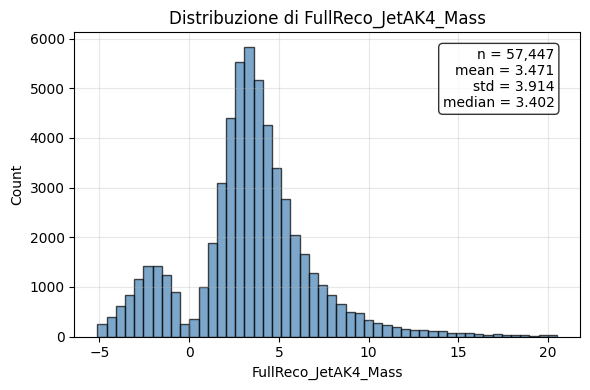

Appiattimento colonna: FullReco_PFCand_PT
  Trovati 39,841,404 valori validi

--- FullReco_PFCand_PT ---
  Elementi validi: 39,761,821
  Range dati: [0.061, 9.992]


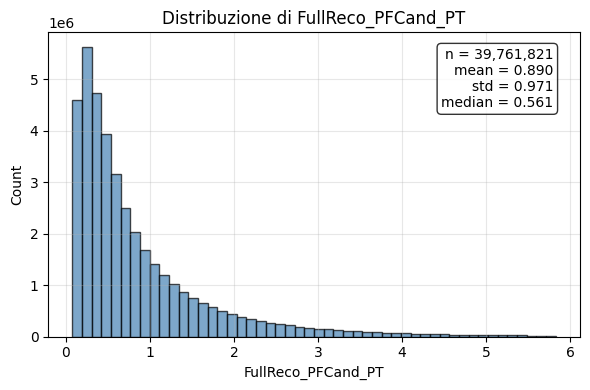

Appiattimento colonna: FullReco_PFCand_Eta
  Trovati 39,841,404 valori validi

--- FullReco_PFCand_Eta ---
  Elementi validi: 39,777,149
  Range dati: [-4.984, 4.984]


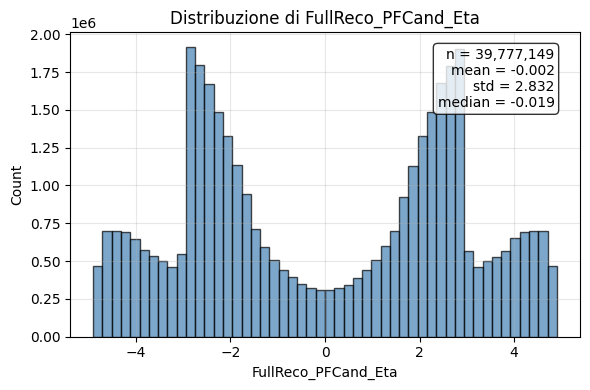

Appiattimento colonna: FullReco_PFCand_Phi
  Trovati 39,841,404 valori validi

--- FullReco_PFCand_Phi ---
  Elementi validi: 39,766,837
  Range dati: [-3.135, 3.135]


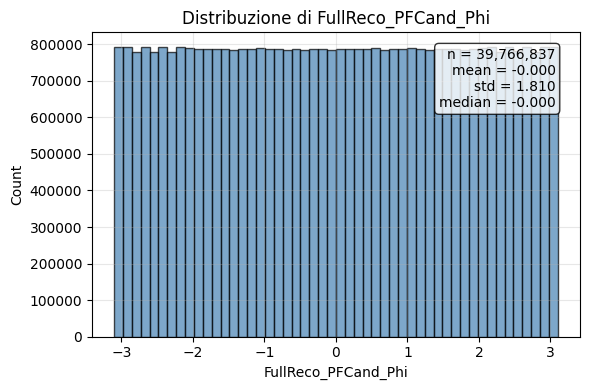

Appiattimento colonna: FullReco_PFCand_Charge
  Trovati 39,841,404 valori validi

--- FullReco_PFCand_Charge ---
  Elementi validi: 39,841,404
  Range dati: [-1.000, 1.000]


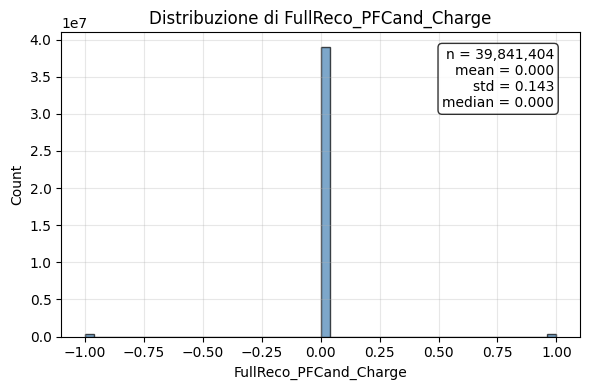

Appiattimento colonna: FullReco_PFCand_Mass
  Trovati 39,841,404 valori validi

--- FullReco_PFCand_Mass ---
  Elementi validi: 39,800,453
  Range dati: [-0.000, 0.938]


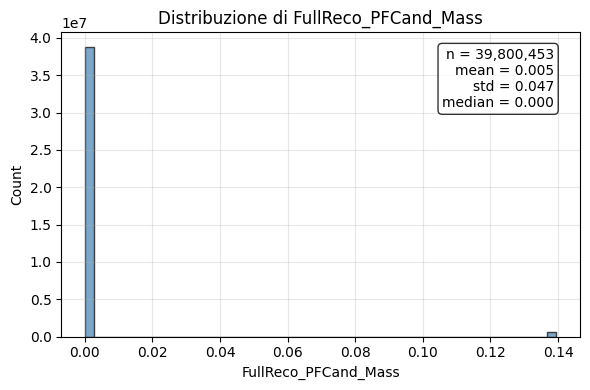


--- invariant_mass ---
  Elementi validi: 3,637
  Range dati: [14.695, 244.375]


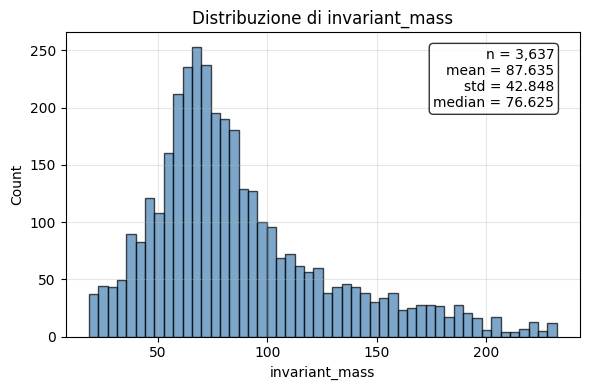

In [4]:
# Crea l'istogramma
maker = SafeHistogramMaker(ddf_im, verbose=True)
plot_columns = ["FullReco_JetAK4_PT", "FullReco_JetAK4_Eta", "FullReco_JetAK4_Phi", "FullReco_JetAK4_Charge", "FullReco_JetAK4_Mass",
                "FullReco_PFCand_PT",    "FullReco_PFCand_Eta",    "FullReco_PFCand_Phi",    "FullReco_PFCand_Charge",    "FullReco_PFCand_Mass",
                "invariant_mass"]
maker.make_histograms_for_columns(plot_columns, bins=50)


--- FullReco_PFCand_Mass ---
  Elementi validi: 39,800,453
  Range dati: [-0.000, 0.938]


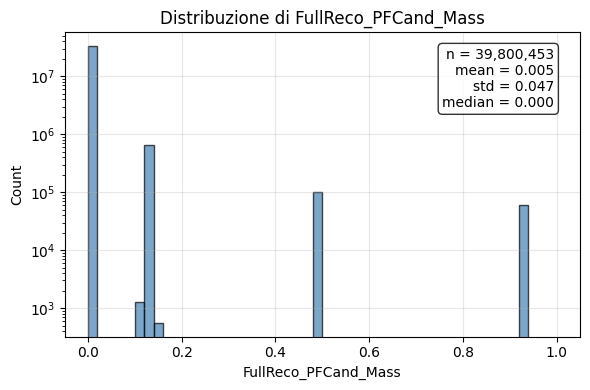

In [5]:
maker.make_histograms_for_columns(['FullReco_PFCand_Mass'], bins=50, range_dict={'FullReco_PFCand_Mass': (0, 1)}, log_scale=True)


--- charge_control ---
  Elementi validi: 4,561
  Range dati: [-7.000, 6.000]


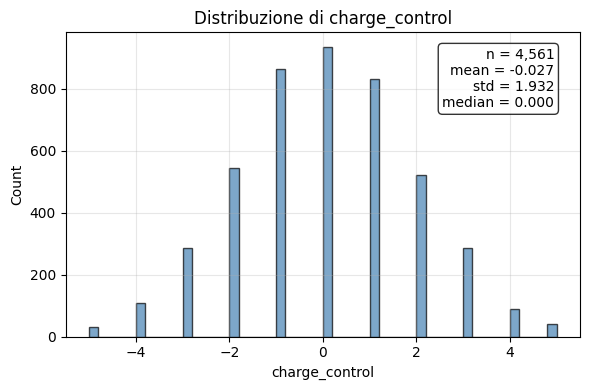


--- pt_control ---
  Elementi validi: 4,462
  Range dati: [-0.832, 0.467]


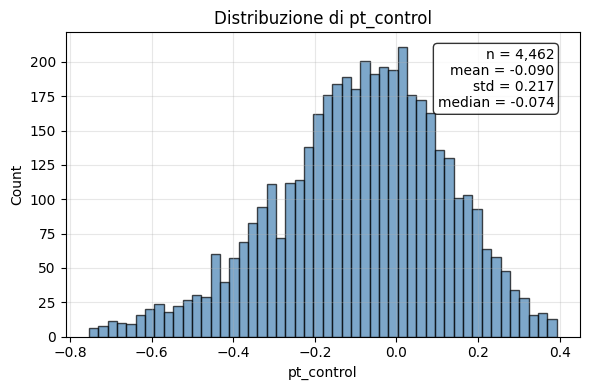


--- mass_control ---
  Elementi validi: 2,730
  Range dati: [-0.660, 11.469]


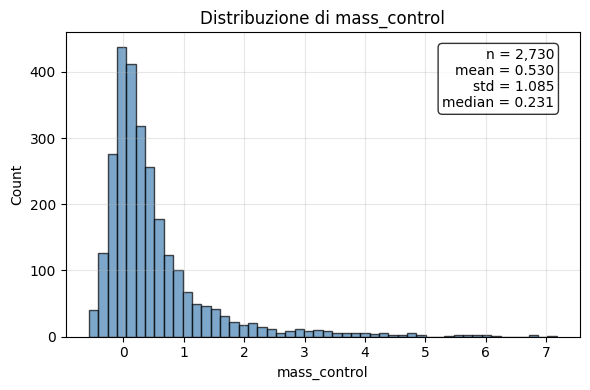


--- n_constituents ---
  Elementi validi: 4,560
  Range dati: [3.000, 53.000]


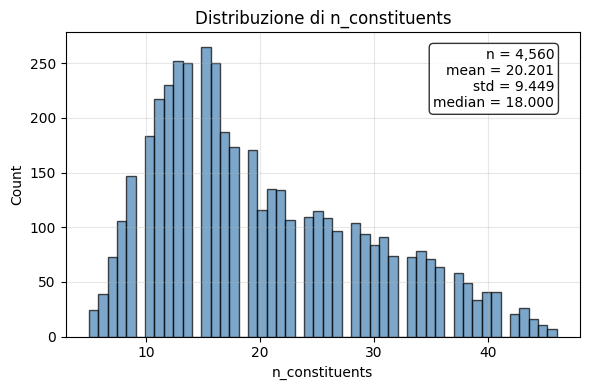


--- distance ---
  Elementi validi: 4,561
  Range dati: [0.000, 2.027]


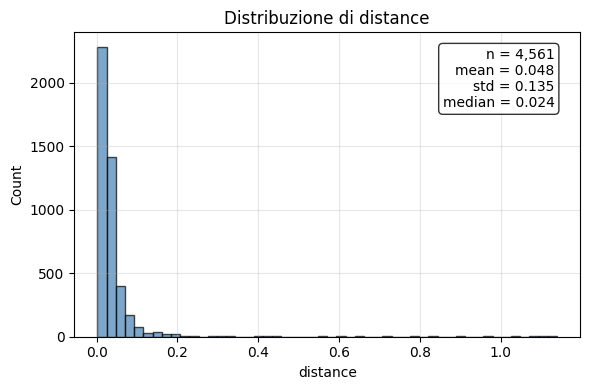

In [6]:
ddf_control = add_jet_control_parameters(ddf, min_jet_pt = 50, no_22 = True, no_neg_jet_m = True)

# Crea l'istogramma per parametri di controllo
maker_control = SafeHistogramMaker(ddf_control, verbose=True)

maker_control.make_all_histograms(bins=50)


--- charge_control ---
  Elementi validi: 5,058
  Range dati: [-7.000, 6.000]


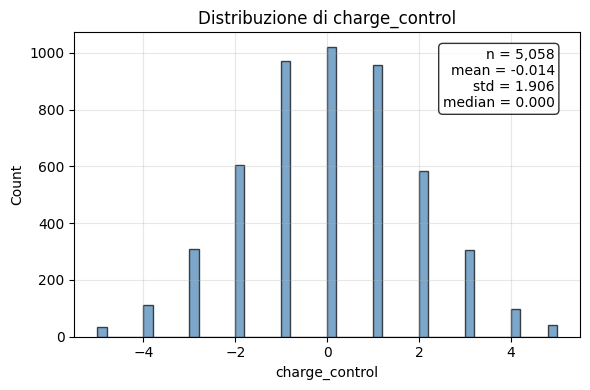


--- pt_control ---
  Elementi validi: 4,957
  Range dati: [-0.922, 0.490]


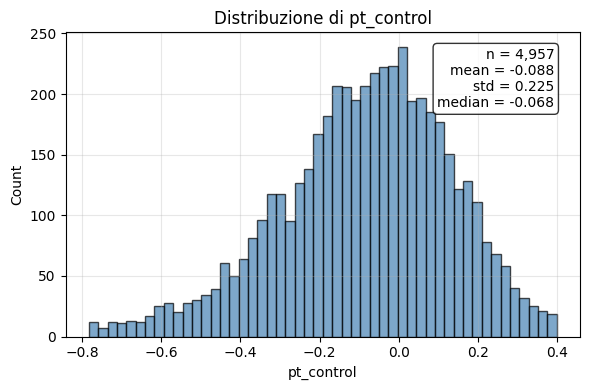


--- mass_control ---
  Elementi validi: 3,045
  Range dati: [-13.836, 10.938]


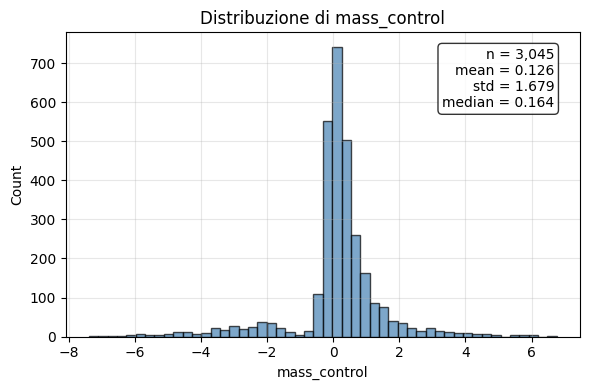


--- n_constituents ---
  Elementi validi: 5,056
  Range dati: [2.000, 53.000]


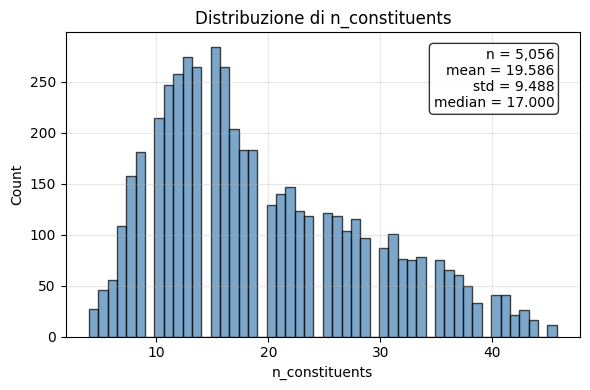

KeyboardInterrupt: 

In [7]:
ddf_control = add_jet_control_parameters(ddf, min_jet_pt = 50, no_22 = True, no_neg_jet_m = False)

# Crea l'istogramma per parametri di controllo
maker_control = SafeHistogramMaker(ddf_control, verbose=True)

maker_control.make_all_histograms(bins=50)

In [ ]:
ddf_control = add_jet_control_parameters(ddf, min_jet_pt = 50, no_22 = True, no_neg_jet_m = True)
maker_control = SafeHistogramMaker(ddf_control, verbose=True)
maker_control.make_histograms_for_columns(['n_constituents', 'distance'], bins=50, range_dict={'n_constituents': (0, 50), 'distance': (0, 0.3)})

In [ ]:
from modules.add_jet_control_parameters_puppi import add_jet_control_parameters_puppi

parameters_puppi = [
    # Jets
    "FullReco_JetPuppiAK4_PT",
    "FullReco_JetPuppiAK4_Eta",
    "FullReco_JetPuppiAK4_Phi",
    "FullReco_JetPuppiAK4_Mass",
    "FullReco_JetPuppiAK4_Charge",
    "FullReco_JetPuppiAK4_Constituents",

    #Contituents
    "FullReco_PUPPIPart_PT",
    "FullReco_PUPPIPart_Eta",
    "FullReco_PUPPIPart_Phi",
    "FullReco_PUPPIPart_Charge",
    "FullReco_PUPPIPart_Mass",
    "FullReco_PUPPIPart_fUniqueID",
    "FullReco_PUPPIPart_PID"
]

ddf_puppi = dd.read_parquet(file_path, parameters_puppi)

ddf_control_puppi = add_jet_control_parameters_puppi(ddf_puppi, min_jet_pt = 50, no_22 = True, no_neg_jet_m = True)

# Crea l'istogramma per parametri di controllo
maker_control_puppi = SafeHistogramMaker(ddf_control_puppi, verbose=True)

maker_control_puppi.make_all_histograms(bins=50)

In [ ]:
maker_control_puppi.make_histograms_for_columns(['n_constituents', 'distance'], bins=26, range_dict={'n_constituents': (0, 26), 'distance': (0, 0.3)})

In [8]:
import dask.dataframe as dd

# Leggi il Dask DataFrame
ddf_test = dd.read_parquet(file_path)

# I nomi delle colonne sono accessibili allo stesso modo
nomi_colonne = ddf_test.columns.tolist()
print(np.vstack(nomi_colonne))

[['FullReco_PFCand_PT']
 ['FullReco_PFCand_Eta']
 ['FullReco_PFCand_Phi']
 ['FullReco_PFCand_PID']
 ['FullReco_PFCand_Charge']
 ['FullReco_PFCand_Mass']
 ['FullReco_PFCand_D0']
 ['FullReco_PFCand_DZ']
 ['FullReco_PFCand_ErrorD0']
 ['FullReco_PFCand_ErrorDZ']
 ['FullReco_PFCand_fUniqueID']
 ['FullReco_PFCand_PuppiW']
 ['FullReco_PUPPIPart_PT']
 ['FullReco_PUPPIPart_Eta']
 ['FullReco_PUPPIPart_Phi']
 ['FullReco_PUPPIPart_Charge']
 ['FullReco_PUPPIPart_Mass']
 ['FullReco_PUPPIPart_PID']
 ['FullReco_PUPPIPart_D0']
 ['FullReco_PUPPIPart_DZ']
 ['FullReco_PUPPIPart_ErrorD0']
 ['FullReco_PUPPIPart_ErrorDZ']
 ['FullReco_PUPPIPart_fUniqueID']
 ['FullReco_PUPPIPart_PuppiW']
 ['FullReco_Electron_PT']
 ['FullReco_Electron_Eta']
 ['FullReco_Electron_Phi']
 ['FullReco_Electron_EhadOverEem']
 ['FullReco_Electron_IsolationVarRhoCorr']
 ['FullReco_MuonTight_PT']
 ['FullReco_MuonTight_Eta']
 ['FullReco_MuonTight_Phi']
 ['FullReco_MuonTight_IsolationVarRhoCorr']
 ['FullReco_PhotonTight_PT']
 ['FullReco_Ph

In [ ]:
n=30
gen_jet_pt = ddf_test['FullReco_GenJetAK4_PT'].head(n)
gen_jet_eta = ddf_test['FullReco_GenJetAK4_Eta'].head(n)
gen_jet_phi = ddf_test['FullReco_GenJetAK4_Phi'].head(n)

jet_pt = ddf_test['FullReco_JetAK4_PT'].head(n)
jet_eta = ddf_test['FullReco_JetAK4_Eta'].head(n)
jet_phi = ddf_test['FullReco_JetAK4_Phi'].head(n)

print("#" * 50)
print("\t" * 2 , " gen jet pt")
print("#" * 50)
print(gen_jet_pt)
print("\n")

print("#" * 50)
print("\t" * 2 , " reco jet pt")
print("#" * 50)
print(jet_pt)


print("#" * 50)
print("\t" * 2 , " gen jet eta")
print("#" * 50)
print(gen_jet_eta)
print("\n")

print("#" * 50)
print("\t" * 2 , " reco jet eta")
print("#" * 50)
print(jet_eta)


print("#" * 50)
print("\t" * 2 , " gen jet phi")
print("#" * 50)
print(gen_jet_phi)
print("\n")

print("#" * 50)
print("\t" * 2 , " reco jet phi")
print("#" * 50)
print(jet_phi)